In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("practice.csv")
df.size

66

In [3]:
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [4]:
df.fillna(50)

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,50.0,Canada,Female,62000.0
3,3,Alex,50.0,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,50.0
5,5,Li Wei,27.0,China,Male,51000.0
6,6,50,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,50,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,50.0,Mexico,Male,45000.0


In [9]:
# task is to shift id as last column
df2 = df.copy()
new_col = [col for col in df.columns if col != "id"]+["id"]  # here we use list comprehension + is used for list concatenationkon side se baat l
print(df2[new_col])

            name   age country   gender   income  id
0       John Doe  29.0     USA     Male  55000.0   1
1       John Doe  29.0     USA     Male  55000.0   1
2     Jane Smith   NaN  Canada   Female  62000.0   2
3           Alex   NaN     USA  Unknown  47000.0   3
4   Maria Garcia  34.0   Spain   Female      NaN   4
5         Li Wei  27.0   China     Male  51000.0   5
6            NaN  45.0   India   Female  73000.0   6
7     Ahmed Khan  38.0     NaN     Male  68000.0   7
8     Rachel Lee  29.0     USA   Female  62000.0   8
9    Carlos Ruiz   NaN  Mexico     Male  45000.0   9
10   Emily Davis  31.0     USA      NaN  58000.0  10


In [20]:
df2 = df.copy()
df2 = df2.drop_duplicates()  # drop duplicate rows
df2 = df2.fillna(0) # fill NaN to value 0
df2 = df2.sort_values("income")  # sort df onbasis on income in ascending order for desc sort_values(["income","age"],ascending = False)
df2 = df2.reset_index(drop=True) # here we drop label 
df2.to_csv("sorted_data.csv")

In [41]:
df2

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [43]:
# aggregation and groupby
# for using aggregation function necessary condition is groupby on basis of any column
# aggregate functions are : min(),max(),mean()...etc
df2 = df.copy()
print(df2.groupby('country')["income"].mean())  # mean income of every country
print(df2.groupby("country")["income"].min())
print(df2.groupby("country")["income"].max())

# groupby on basis of gender
gender_group = df2.groupby("gender")
gender_group['income'].mean()  # on basis of gender the mean value of each gender


country
Canada    62000.0
China     51000.0
India     73000.0
Mexico    45000.0
Spain         NaN
USA       55400.0
Name: income, dtype: float64
country
Canada    62000.0
China     51000.0
India     73000.0
Mexico    45000.0
Spain         NaN
USA       47000.0
Name: income, dtype: float64
country
Canada    62000.0
China     51000.0
India     73000.0
Mexico    45000.0
Spain         NaN
USA       62000.0
Name: income, dtype: float64


gender
Female     65666.666667
Male       54800.000000
Unknown    47000.000000
Name: income, dtype: float64

In [45]:
# aggregate or agg function it takes multiple aggregate function at one time and apply individual changes simultaneously
df2.groupby("country")["income"].agg(["mean","max","min"])
df2.groupby("country")["income"].aggregate(["mean","max","min"])
# above two are same but we use abbreviation 
# we can pass column name also after applying aggregation function
print(df2.groupby("country")["income"].agg(avg_sal = "mean",max_sal = "max",min_sal = "min"))

# we can apply different agg function on different col
print(df2.groupby("country").agg({    
    "income":"mean",
    "age":"max"
})) # here we are finding mean of income and max of age of every country
# here we are finding mean of income and max of age of every country with column name as desired name
df2.groupby("country").agg(
    avg_sal = ("income","mean"),
    max_age = ("age","max")
)


         avg_sal  max_sal  min_sal
country                           
Canada   62000.0  62000.0  62000.0
China    51000.0  51000.0  51000.0
India    73000.0  73000.0  73000.0
Mexico   45000.0  45000.0  45000.0
Spain        NaN      NaN      NaN
USA      55400.0  62000.0  47000.0
          income   age
country               
Canada   62000.0   NaN
China    51000.0  27.0
India    73000.0  45.0
Mexico   45000.0   NaN
Spain        NaN  34.0
USA      55400.0  31.0


,avg_sal,max_age
country,,
Canada,62000.0,NaN
China,51000.0,27.0
India,73000.0,45.0
Mexico,45000.0,NaN
Spain,NaN,34.0
USA,55400.0,31.0


In [57]:
'''
🔹 Melt (Unpivot)
melt(id_vars,value_vars,var_name,value_name)
    keep, unpivot,  newColName,  newColValue
Melt converts wide format → long format.

When you have many columns representing similar types of data (like years, subjects, months), melt() converts those columns into rows.
| id | Jan | Feb | Mar |
| -- | --- | --- | --- |
| 1  | 10  | 20  | 30  |
After melt:
| id | Month | Sales |
| -- | ----- | ----- |
| 1  | Jan   | 10    |
| 1  | Feb   | 20    |
| 1  | Mar   | 30    |
👉 So melt:

Reduces number of columns

Increases number of rows

Converts horizontal data into vertical structure

⚠️ Melt is NOT transpose. 


🔹 Pivot
pivot(index, columns, values)
      keep, newCol, newVal
Pivot converts long format → wide format.

It does the opposite of melt.
    | id | Month | Sales |
| -- | ----- | ----- |
| 1  | Jan   | 10    |
| 1  | Feb   | 20    |
Ater pivot(wide formate)
| id | Jan | Feb |
| -- | --- | --- |
| 1  | 10  | 20  |
👉 Pivot:

Increases number of columns

Reduces number of rows

Spreads row values into columns 
'''

df = pd.DataFrame({
    "country" :["India","Russia","Nepal","Srilanka"],
    "year" :[2020,2021,2020,2021],
    "sales" :[100,120,90,110],
    "profit" :[20,25,18,21],
     "tax" : [5,6,4,5]
})

melted_data =  df.melt(
    id_vars=["country","year"],
    value_vars=['sales','profit','tax'],
    var_name="metrices",
    value_name="value"
)
print(melted_data)
#pivot
original = melted_data.pivot(
    index = ["country","year"],  # chose superkey whose combination is unique
    columns = "metrices",
    values = "value"
)
original



     country  year metrices  value
0      India  2020    sales    100
1     Russia  2021    sales    120
2      Nepal  2020    sales     90
3   Srilanka  2021    sales    110
4      India  2020   profit     20
5     Russia  2021   profit     25
6      Nepal  2020   profit     18
7   Srilanka  2021   profit     21
8      India  2020      tax      5
9     Russia  2021      tax      6
10     Nepal  2020      tax      4
11  Srilanka  2021      tax      5


,metrices,profit,sales,tax
country,year,,,
India,2020,20,100,5
Nepal,2020,18,90,4
Russia,2021,25,120,6
Srilanka,2021,21,110,5


<Axes: xlabel='age', ylabel='income'>

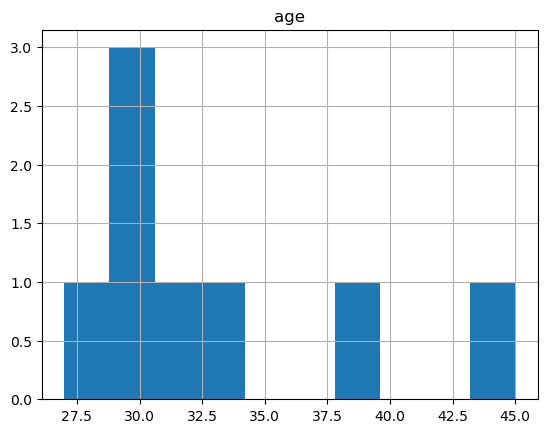

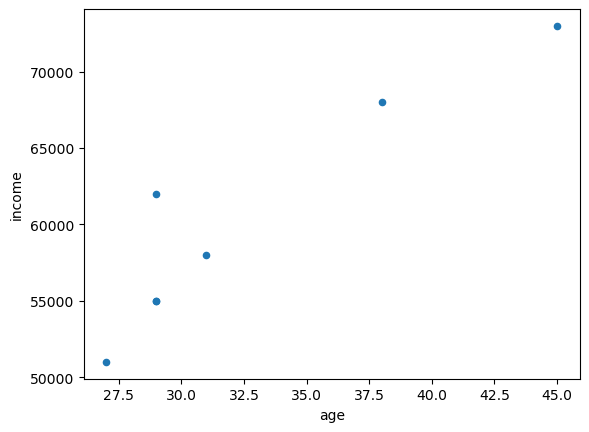

In [64]:
df = pd.read_csv("practice.csv")
df.hist("age")
print()
df.plot(kind="scatter", x = "age",y = "income")

In [73]:
#Pandas 
#Merging & joining Data
'''
inner , left, right, outer join same as sql join 
'''
df_customer = pd.DataFrame({
    "customer_id" : [1,2,3,4],
    "name" : ["Adam","Bob","Charlie","Deva"]
})
print(df_customer)

df_orders = pd.DataFrame({
    "order_id" : [101,102,103,104],
    "customer_id" : [2,1,4,5],
    "amount" : [250,128,300,100]
})
print(df_orders)

print(pd.merge(df_customer,df_orders, on="customer_id")) # innerJoin
print()
print(pd.merge(df_customer,df_orders, on="customer_id", how="left")) # leftJoin
print()
print(pd.merge(df_customer,df_orders, on="customer_id",how="right")) # rightJoin
print()
print(pd.merge(df_customer,df_orders, on="customer_id",how="outer")) # outerJoin

   customer_id     name
0            1     Adam
1            2      Bob
2            3  Charlie
3            4     Deva
   order_id  customer_id  amount
0       101            2     250
1       102            1     128
2       103            4     300
3       104            5     100
   customer_id  name  order_id  amount
0            1  Adam       102     128
1            2   Bob       101     250
2            4  Deva       103     300

   customer_id     name  order_id  amount
0            1     Adam     102.0   128.0
1            2      Bob     101.0   250.0
2            3  Charlie       NaN     NaN
3            4     Deva     103.0   300.0

   customer_id  name  order_id  amount
0            2   Bob       101     250
1            1  Adam       102     128
2            4  Deva       103     300
3            5   NaN       104     100

   customer_id     name  order_id  amount
0            1     Adam     102.0   128.0
1            2      Bob     101.0   250.0
2            3  Charlie  